In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

DATA = Path("../../data/Compiled")
RESULTS = Path("../../results/figures")
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("tab10")

print("Data directory:", DATA.resolve())
print("Files:", sorted(f.name for f in DATA.iterdir()))

Data directory: C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\data\Compiled
Files: ['Animal_location_counts_Breeding_Sheep_Basic_Data.csv', 'Animal_location_counts_Cattle_Basic_Data.csv', 'Animal_location_counts_Lamb_Basic_Data.csv', 'Breeding_Sheep_Basic_Data_Format_1.csv', 'Breeding_Sheep_Location_Data_Format_1.csv', 'Breeding_Sheep_Sales_Data_Format_1.csv', 'Cattle_Basic_Data_Format_1.csv', 'Cattle_Location_Data_Format_1.csv', 'Cattle_Sales_Data_Format_1.csv', 'Feed_Type_Data_Format_1.csv', 'Field_Event_Data_Format_1.csv', 'Field_Survey_Data_Format_1_Botanical_Survey.csv', 'Field_Survey_Data_Format_1_Grain_Survey.csv', 'Field_Survey_Data_Format_1_Herbage_Survey.csv', 'Field_Survey_Data_Format_1_Silage_Cut_Survey.csv', 'Field_Survey_Data_Format_1_Soil_Chemistry__Physics.csv', 'Lamb_Basic_Data_Format_1.csv', 'Lamb_Location_Data_Format_1.csv', 'Lamb_Sales_Data_Format_1.csv', 'greenhouse.csv', 'livestock_condition_score_long.csv', '

# ─── 1. GREENHOUSE EC DATA ──────────────────────────────────────────────────
# Primary target: half-hourly EC fluxes from Tower 2, 2018–present

In [2]:
gh = pd.read_csv(DATA / "greenhouse.csv", parse_dates=["Datetime"], low_memory=False)
gh = gh.sort_values("Datetime").reset_index(drop=True)

print(f"Shape:       {gh.shape}")
print(f"Date range:  {gh['Datetime'].min()} → {gh['Datetime'].max()}")
print(f"Total rows:  {len(gh):,}")

# Identify flux (FCH4) and mole-fraction (CH4) columns separately
# FCH4 = eddy-covariance flux (nmol m⁻² s⁻¹) — this is the target variable
# CH4  = mole fraction (nmol/mol) — ambient concentration, not flux
fch4_cols    = [c for c in gh.columns if c.startswith("FCH4") and "SSITC" not in c and "QUALITY" not in c.upper()]
ch4_frac_cols = [c for c in gh.columns if c.startswith("CH4")  and "SSITC" not in c and "QUALITY" not in c.upper()]
ssitc_cols   = [c for c in gh.columns if "FCH4_SSITC" in c]

# Force numeric
for c in fch4_cols + ch4_frac_cols:
    gh[c] = pd.to_numeric(gh[c], errors="coerce")

print(f"\nFlux columns (FCH4):       {fch4_cols}")
print(f"Mole fraction (CH4):       {ch4_frac_cols}")
print(f"SSITC QC flags:            {ssitc_cols}")

# Coverage per flux column
print("\nCoverage per EC tower:")
for col in fch4_cols:
    n = gh[col].notna().sum()
    print(f"  {col:<40}  {n:>7,}  ({n/len(gh)*100:.1f}%)")

Shape:       (122679, 295)
Date range:  2017-01-01 00:30:00 → 2024-01-01 00:00:00
Total rows:  122,679

Flux columns (FCH4):       ['FCH4_1_1_1 [Tower 2]', 'FCH4_1_1_1 [Tower 4]', 'FCH4_1_1_1 [Tower 9]']
Mole fraction (CH4):       ['CH4_1_1_1 [Tower 2]', 'CH4_1_1_1 [Tower 4]', 'CH4_1_1_1 [Tower 9]']
SSITC QC flags:            ['FCH4_SSITC_TEST_1_1_1 [Tower 2]', 'FCH4_SSITC_TEST_1_1_1 [Tower 4]', 'FCH4_SSITC_TEST_1_1_1 [Tower 9]']

Coverage per EC tower:
  FCH4_1_1_1 [Tower 2]                       14,825  (12.1%)
  FCH4_1_1_1 [Tower 4]                       54,695  (44.6%)
  FCH4_1_1_1 [Tower 9]                       31,416  (25.6%)


In [3]:
# Select the tower with best FCH4 coverage as primary target
# Tower 2 = the reference EC tower per CONTEXT.md
# Check all towers and pick best or confirm Tower 2
best_fch4 = max(fch4_cols, key=lambda c: gh[c].notna().sum())
print(f"Best FCH4 coverage: {best_fch4}")

CH4 = "FCH4_1_1_1 [Tower 2]"  # primary target per project spec
CH4_QC = "FCH4_SSITC_TEST_1_1_1 [Tower 2]"

if CH4_QC in gh.columns:
    gh[CH4_QC] = pd.to_numeric(gh[CH4_QC], errors="coerce")

print(f"\nPrimary flux column:  {CH4}")
print(f"Quality flag column:  {CH4_QC}")

raw = gh[CH4]
print(f"\nRaw FCH4 stats:")
print(f"  Total observations:  {len(raw):,}")
print(f"  Non-null:            {raw.notna().sum():,}  ({raw.notna().mean()*100:.1f}%)")
print(f"  Null / gaps:         {raw.isna().sum():,}  ({raw.isna().mean()*100:.1f}%)")
print(f"\nSSITC QC distribution (0=best, 2=reject):")
print(gh[CH4_QC].value_counts(dropna=False).sort_index().to_string())

Best FCH4 coverage: FCH4_1_1_1 [Tower 4]

Primary flux column:  FCH4_1_1_1 [Tower 2]
Quality flag column:  FCH4_SSITC_TEST_1_1_1 [Tower 2]

Raw FCH4 stats:
  Total observations:  122,679
  Non-null:            14,825  (12.1%)
  Null / gaps:         107,854  (87.9%)

SSITC QC distribution (0=best, 2=reject):
FCH4_SSITC_TEST_1_1_1 [Tower 2]
0.0      7226
1.0      4860
2.0      2739
NaN    107854


In [4]:
# Quality-filtered CH4 series (SSITC flag 0 or 1; drop 2 = reject)
if CH4_QC:
    gh_qc = gh[gh[CH4_QC].isin([0, 1])].copy()
else:
    gh_qc = gh.dropna(subset=[CH4]).copy()

ch4_qc = gh_qc[CH4]
print(f"After QC filter: {len(ch4_qc):,} rows ({len(ch4_qc)/len(gh)*100:.1f}% retained)")
print(f"\nFiltered CH4 distribution:")
print(ch4_qc.describe().round(3))

After QC filter: 12,086 rows (9.9% retained)

Filtered CH4 distribution:
count    12086.000
mean        33.537
std        196.041
min      -1559.019
25%         -1.287
50%          5.966
75%         25.099
max       6160.906
Name: FCH4_1_1_1 [Tower 2], dtype: float64


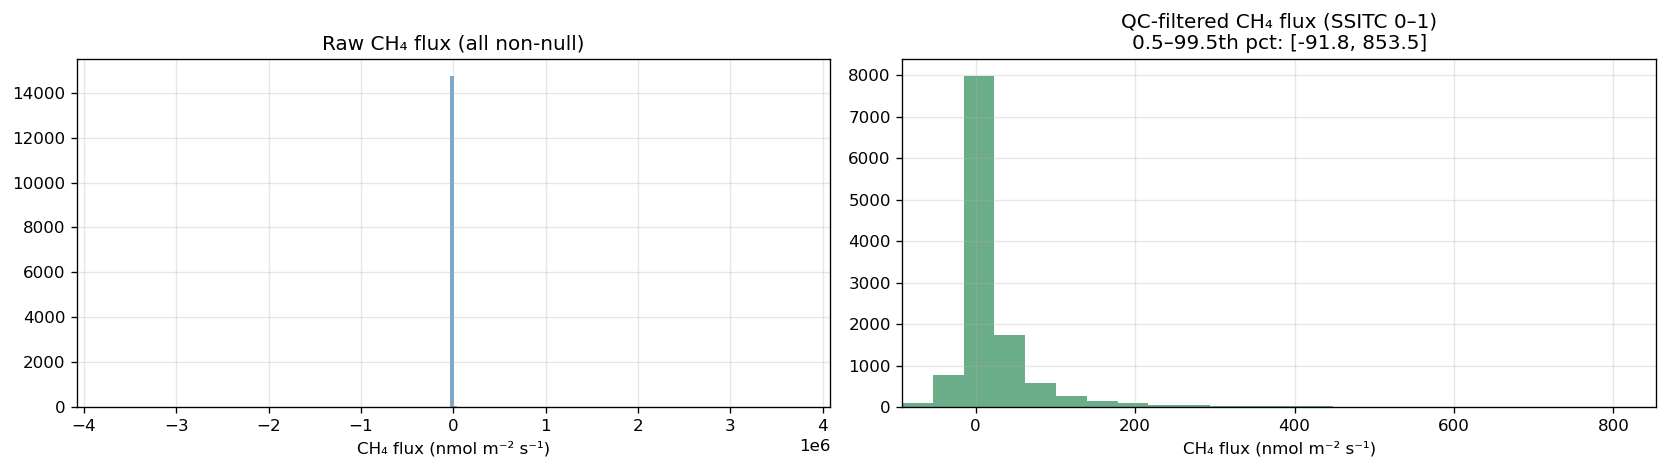

In [5]:
# CH4 flux distribution — raw vs QC-filtered
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(gh[CH4].dropna(), bins=200, color="steelblue", alpha=0.7, edgecolor="none")
axes[0].set_title("Raw CH₄ flux (all non-null)")
axes[0].set_xlabel("CH₄ flux (nmol m⁻² s⁻¹)")

axes[1].hist(ch4_qc, bins=200, color="seagreen", alpha=0.7, edgecolor="none")
# Clip to ±200 to see distribution body
p1, p99 = ch4_qc.quantile([0.005, 0.995])
axes[1].set_xlim(p1, p99)
axes[1].set_title(f"QC-filtered CH₄ flux (SSITC 0–1)\n0.5–99.5th pct: [{p1:.1f}, {p99:.1f}]")
axes[1].set_xlabel("CH₄ flux (nmol m⁻² s⁻¹)")

plt.tight_layout()
plt.savefig(RESULTS / "ch4_distribution.png", bbox_inches="tight")
plt.show()

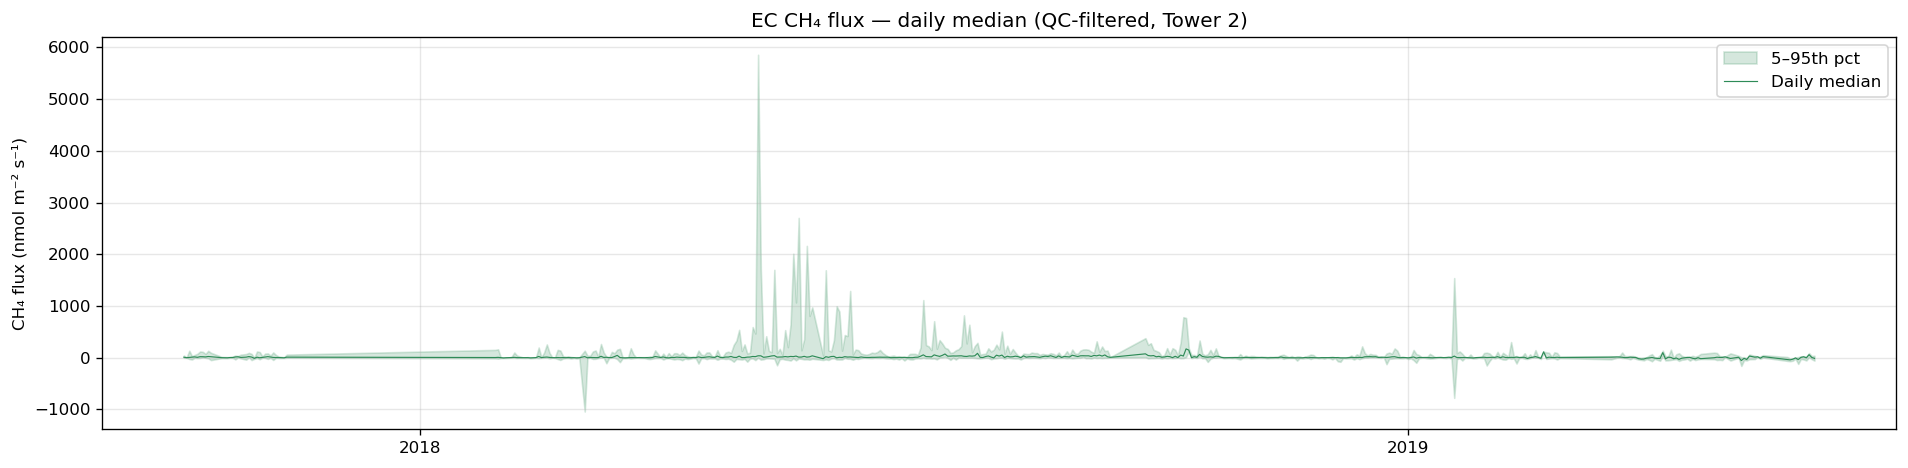

In [6]:
# Full time series of QC-filtered CH4 flux — daily median ribbon
gh_qc["date"] = gh_qc["Datetime"].dt.date

grp = gh_qc.groupby("date")[CH4]
daily_agg = pd.DataFrame({
    "q05":    grp.quantile(0.05),
    "median": grp.quantile(0.50),
    "q95":    grp.quantile(0.95),
})
daily_agg.index = pd.to_datetime(daily_agg.index)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily_agg.index, daily_agg["q05"], daily_agg["q95"], alpha=0.2, color="seagreen", label="5–95th pct")
ax.plot(daily_agg.index, daily_agg["median"], lw=0.7, color="seagreen", label="Daily median")
ax.set_title("EC CH₄ flux — daily median (QC-filtered, Tower 2)")
ax.set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "ch4_timeseries.png", bbox_inches="tight")
plt.show()

In [7]:
# Gap analysis — identify contiguous missing blocks in CH4 column
gh_full = gh.set_index("Datetime").asfreq("30min")  # reindex to regular 30-min grid
ch4_series = gh_full[CH4]

is_missing = ch4_series.isna()
# if SSITC available, also flag QC=2 as "bad"
if CH4_QC and CH4_QC in gh_full.columns:
    is_missing = is_missing | (gh_full[CH4_QC] == 2)

# Find gap runs
gap_starts = is_missing[is_missing & ~is_missing.shift(1, fill_value=False)].index
gap_ends   = is_missing[is_missing & ~is_missing.shift(-1, fill_value=False)].index
gaps = pd.DataFrame({"start": gap_starts, "end": gap_ends})
gaps["duration_days"] = (gaps["end"] - gaps["start"]).dt.total_seconds() / 86400
gaps["duration_steps"] = ((gaps["end"] - gaps["start"]).dt.total_seconds() / 1800 + 1).astype(int)

print(f"Total missing/bad half-hours: {is_missing.sum():,}  ({is_missing.mean()*100:.1f}%)")
print(f"Number of contiguous gaps:    {len(gaps):,}")
print(f"\nGap duration distribution (days):")
print(gaps["duration_days"].describe().round(2))
print(f"\nGaps > 12 days (long gaps — Zhu 2023 threshold): {(gaps['duration_days'] > 12).sum()}")
print(f"Gaps > 30 days: {(gaps['duration_days'] > 30).sum()}")
print(f"\nTop 10 longest gaps:")
print(gaps.nlargest(10, "duration_days")[["start","end","duration_days"]].to_string(index=False))

Total missing/bad half-hours: 110,602  (90.1%)
Number of contiguous gaps:    2,887

Gap duration distribution (days):
count    2887.00
mean        0.78
std        31.64
min         0.00
25%         0.00
50%         0.00
75%         0.04
max      1675.19
Name: duration_days, dtype: float64

Gaps > 12 days (long gaps — Zhu 2023 threshold): 5
Gaps > 30 days: 3

Top 10 longest gaps:
              start                 end  duration_days
2019-05-31 19:30:00 2024-01-01 00:00:00    1675.187500
2017-01-01 00:30:00 2017-10-06 11:30:00     278.458333
2017-11-13 11:00:00 2018-01-29 09:30:00      76.937500
2019-02-26 04:30:00 2019-03-17 09:00:00      19.187500
2018-09-13 10:00:00 2018-09-26 12:00:00      13.083333
2019-05-12 20:30:00 2019-05-21 08:30:00       8.500000
2019-04-19 10:00:00 2019-04-24 14:00:00       5.166667
2017-10-16 02:30:00 2017-10-20 05:30:00       4.125000
2018-05-26 18:30:00 2018-05-30 11:30:00       3.708333
2019-04-30 15:30:00 2019-05-03 09:00:00       2.729167


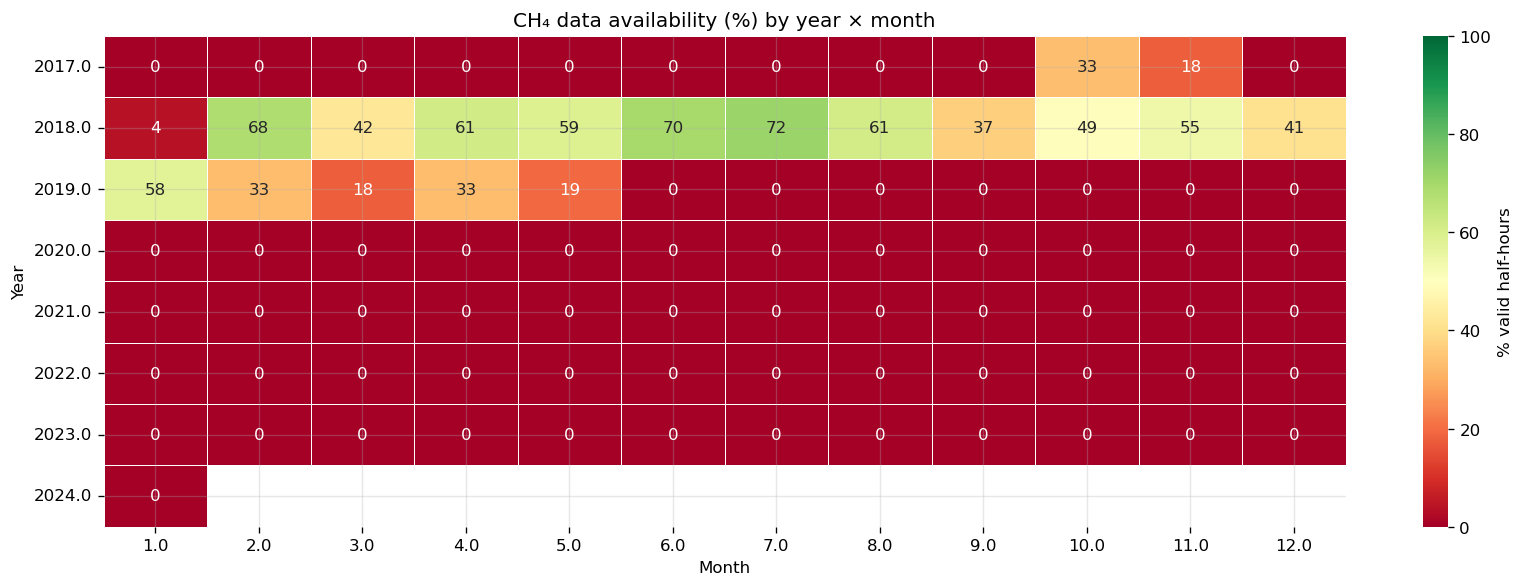

In [8]:
# Data availability heatmap — fraction of valid CH4 per month x year
gh["year"]  = gh["Datetime"].dt.year
gh["month"] = gh["Datetime"].dt.month

if CH4_QC and CH4_QC in gh.columns:
    gh["ch4_valid"] = gh[CH4].notna() & (gh[CH4_QC] != 2)
else:
    gh["ch4_valid"] = gh[CH4].notna()

avail_raw = gh.groupby(["year","month"])["ch4_valid"].mean().reset_index()
avail_raw.columns = ["year","month","pct"]
avail_raw["pct"] *= 100
avail = avail_raw.pivot_table(index="year", columns="month", values="pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(avail, ax=ax, cmap="RdYlGn", vmin=0, vmax=100, annot=True, fmt=".0f",
            linewidths=0.5, cbar_kws={"label": "% valid half-hours"})
ax.set_title("CH₄ data availability (%) by year × month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig(RESULTS / "ch4_availability_heatmap.png", bbox_inches="tight")
plt.show()

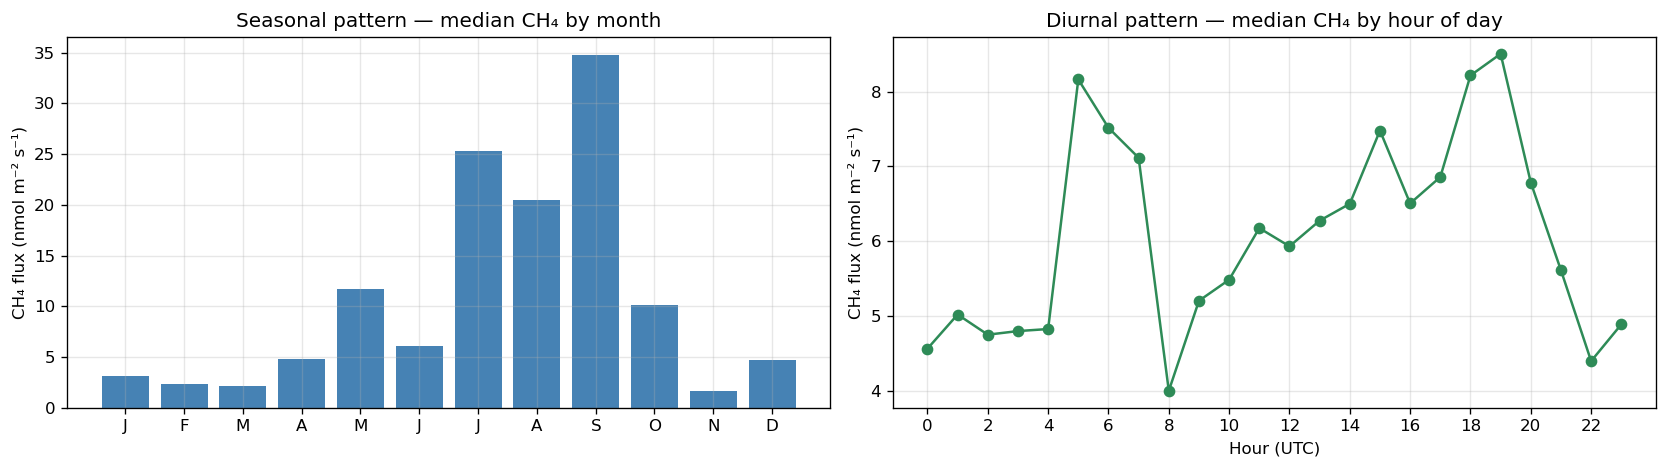

In [9]:
# Seasonal and diurnal patterns (QC-filtered data)
gh_qc["month"] = gh_qc["Datetime"].dt.month
gh_qc["hour"]  = gh_qc["Datetime"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Seasonal: median CH4 by month
monthly = gh_qc.groupby("month")[CH4].median()
axes[0].bar(monthly.index, monthly.values, color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[0].set_title("Seasonal pattern — median CH₄ by month")
axes[0].set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")

# Diurnal: median CH4 by hour-of-day
hourly = gh_qc.groupby("hour")[CH4].median()
axes[1].plot(hourly.index, hourly.values, marker="o", color="seagreen")
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title("Diurnal pattern — median CH₄ by hour of day")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")

plt.tight_layout()
plt.savefig(RESULTS / "ch4_seasonal_diurnal.png", bbox_inches="tight")
plt.show()

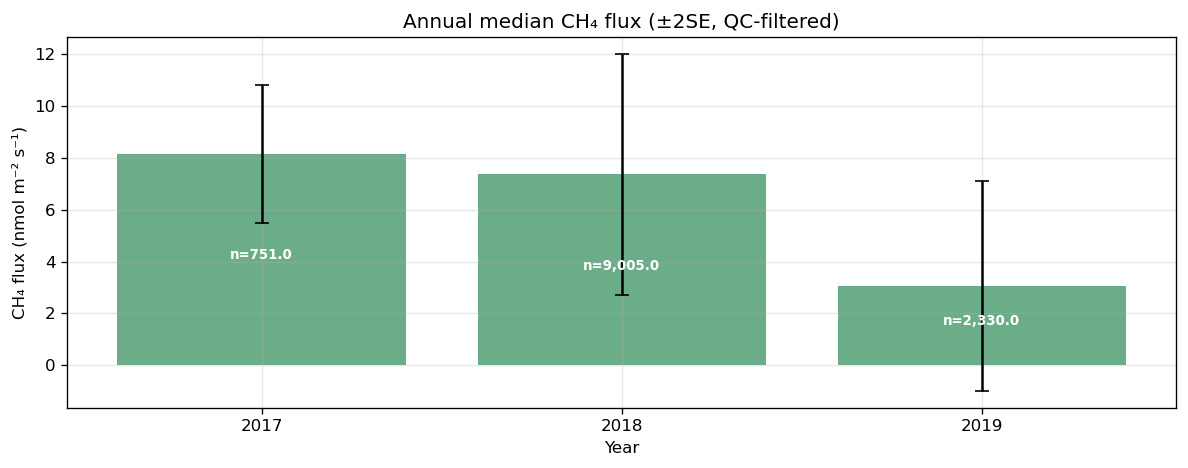

 year   median        std    n       se
 2017 8.160599  36.457554  751 1.330355
 2018 7.368523 220.624562 9005 2.324941
 2019 3.064421  97.847919 2330 2.027093


In [10]:
# Interannual variability — annual median CH4 flux
gh_qc["year"] = gh_qc["Datetime"].dt.year
annual_ch4 = gh_qc.groupby("year")[CH4].agg(["median","std","count"]).reset_index()
annual_ch4.columns = ["year","median","std","n"]
annual_ch4["se"] = annual_ch4["std"] / np.sqrt(annual_ch4["n"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(annual_ch4["year"], annual_ch4["median"], yerr=annual_ch4["se"]*2,
       color="seagreen", alpha=0.7, capsize=4)
for _, row in annual_ch4.iterrows():
    ax.text(row["year"], row["median"]/2, f'n={row["n"]:,}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_title("Annual median CH₄ flux (±2SE, QC-filtered)")
ax.set_xlabel("Year")
ax.set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")
ax.set_xticks(annual_ch4["year"])
plt.tight_layout()
plt.savefig(RESULTS / "ch4_annual.png", bbox_inches="tight")
plt.show()
print(annual_ch4.to_string(index=False))

EC variables selected for correlation: {'CO2': 'CO2_1_1_1 [Tower 2]', 'H': 'H_1_1_1 [Tower 2]', 'LE': 'LE_1_1_1 [Tower 2]', 'H2O': 'H2O_1_1_1 [Tower 2]', 'CH4': 'FCH4_1_1_1 [Tower 2]'}


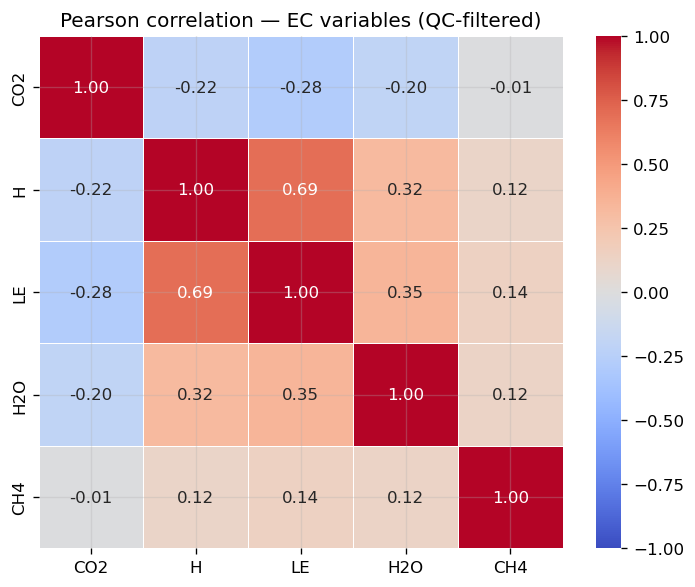

In [11]:
# Other EC variables — CO2, H, LE correlation with CH4
ec_candidates = ["CO2", "H_", "LE_", "H2O"]
ec_cols = {}
for tag in ec_candidates:
    cols = [c for c in gh.columns if tag in c and "QUALITY" not in c.upper() 
            and "TEST" not in c.upper() and "LAST" not in c.upper() and "SSITC" not in c.upper()]
    if cols:
        ec_cols[tag.strip("_")] = cols[0]
        
ec_cols["CH4"] = CH4
print("EC variables selected for correlation:", ec_cols)

# Build a clean subset
ec_df = gh_qc[["Datetime"] + list(ec_cols.values())].copy()
ec_df.columns = ["Datetime"] + list(ec_cols.keys())
ec_df = ec_df.dropna()

corr = ec_df.drop(columns="Datetime").corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Pearson correlation — EC variables (QC-filtered)")
plt.tight_layout()
plt.savefig(RESULTS / "ec_correlation.png", bbox_inches="tight")
plt.show()

# ─── 2. ENVIRONMENTAL MEASUREMENTS ─────────────────────────────────────────
# Water flow (l/s) and soil moisture (%) across ≤15 catchments, 15-min resolution

In [12]:
ms = pd.read_csv(DATA / "measurements.csv", parse_dates=["Datetime"], low_memory=False)
ms = ms.sort_values("Datetime").reset_index(drop=True)

print(f"Shape:       {ms.shape}")
print(f"Date range:  {ms['Datetime'].min()} → {ms['Datetime'].max()}")
print(f"Total rows:  {len(ms):,}")

# Separate data columns from quality/timestamp columns
qc_mask  = ms.columns.str.contains("Quality", case=False)
ts_mask  = ms.columns.str.contains("Last Modified", case=False)
data_cols = ms.columns[~qc_mask & ~ts_mask & (ms.columns != "Datetime")].tolist()

flow_cols = [c for c in data_cols if "Flow" in c]
sm_cols   = [c for c in data_cols if "Soil Moisture" in c]
print(f"\nFlow columns ({len(flow_cols)}): {flow_cols[:5]}{'...' if len(flow_cols)>5 else ''}")
print(f"Soil moisture columns ({len(sm_cols)}): {sm_cols[:5]}{'...' if len(sm_cols)>5 else ''}")

Shape:       (280608, 718)
Date range:  2017-01-01 00:15:00 → 2025-01-02 00:00:00
Total rows:  280,608

Flow columns (30): ['Flow (l/s) [Catchment 1]', 'Flow (l/s) [Catchment 2]', 'Flow (l/s) [Catchment 3]', 'Flow (l/s) [Catchment 4 After  2013/08/13]', 'Flow (l/s) [Catchment 5]']...
Soil moisture columns (15): ['Soil Moisture @ 10cm Depth (%) [Catchment 1]', 'Soil Moisture @ 10cm Depth (%) [Catchment 2]', 'Soil Moisture @ 10cm Depth (%) [Catchment 3]', 'Soil Moisture @ 10cm Depth (%) [Catchment 4 After  2013/08/13]', 'Soil Moisture @ 10cm Depth (%) [Catchment 5]']...


In [13]:
# Apply quality filter: keep only "Acceptable" readings
def apply_qc_filter(df, data_col):
    qc_col = data_col + " Quality"
    if qc_col in df.columns:
        return df[data_col].where(df[qc_col] == "Acceptable")
    return df[data_col]

# Build quality-filtered matrices for flow and soil moisture
ms_flow_qc = pd.DataFrame({"Datetime": ms["Datetime"]})
for c in flow_cols:
    ms_flow_qc[c] = apply_qc_filter(ms, c)

ms_sm_qc = pd.DataFrame({"Datetime": ms["Datetime"]})
for c in sm_cols:
    ms_sm_qc[c] = apply_qc_filter(ms, c)

# Availability % per column
flow_avail = ms_flow_qc[flow_cols].notna().mean() * 100
sm_avail   = ms_sm_qc[sm_cols].notna().mean() * 100

print("Flow data availability % (QC-filtered):")
print(flow_avail.round(1).to_string())
print("\nSoil moisture availability % (QC-filtered):")
print(sm_avail.round(1).to_string())

Flow data availability % (QC-filtered):
Flow (l/s) [Catchment 1]                                            79.7
Flow (l/s) [Catchment 2]                                            63.9
Flow (l/s) [Catchment 3]                                            80.7
Flow (l/s) [Catchment 4 After  2013/08/13]                          66.8
Flow (l/s) [Catchment 5]                                            80.3
Flow (l/s) [Catchment 6]                                            80.7
Flow (l/s) [Catchment 7]                                            83.4
Flow (l/s) [Catchment 8]                                            80.3
Flow (l/s) [Catchment 9]                                            82.1
Flow (l/s) [Catchment 10]                                           82.4
Flow (l/s) [Catchment 11]                                           83.7
Flow (l/s) [Catchment 12]                                           69.7
Flow (l/s) [Catchment 13]                                           81.5
Flow (l/s) 

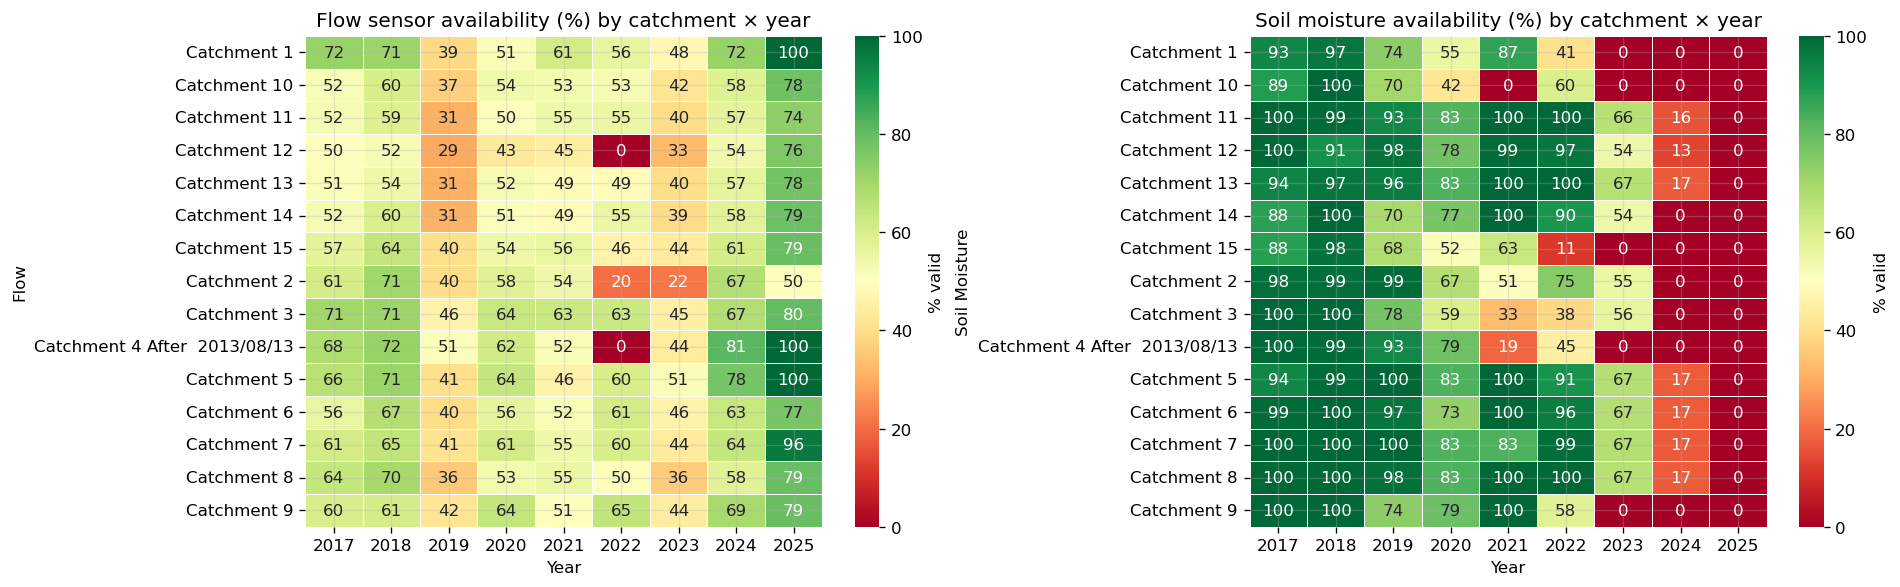

In [14]:
# Sensor availability heatmap: fraction of valid readings per catchment × year
ms["year"] = ms["Datetime"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cols, title, label in [
    (axes[0], flow_cols, "Flow sensor availability (%) by catchment × year", "Flow"),
    (axes[1], sm_cols,   "Soil moisture availability (%) by catchment × year", "Soil Moisture"),
]:
    avail_rows = []
    for col in cols:
        catchment = col.split("[")[-1].rstrip("]").strip() if "[" in col else col
        for yr, grp in ms.groupby("year"):
            valid_pct = apply_qc_filter(grp, col).notna().mean() * 100
            avail_rows.append({"catchment": catchment, "year": yr, "avail": valid_pct})
    if not avail_rows:
        ax.set_title(f"No {label} columns found")
        continue
    avail_df = (pd.DataFrame(avail_rows)
                  .pivot_table(index="catchment", columns="year", values="avail", aggfunc="mean"))
    
    sns.heatmap(avail_df, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.3, cbar_kws={"label": "% valid"})
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(RESULTS / "measurements_availability.png", bbox_inches="tight")
plt.show()

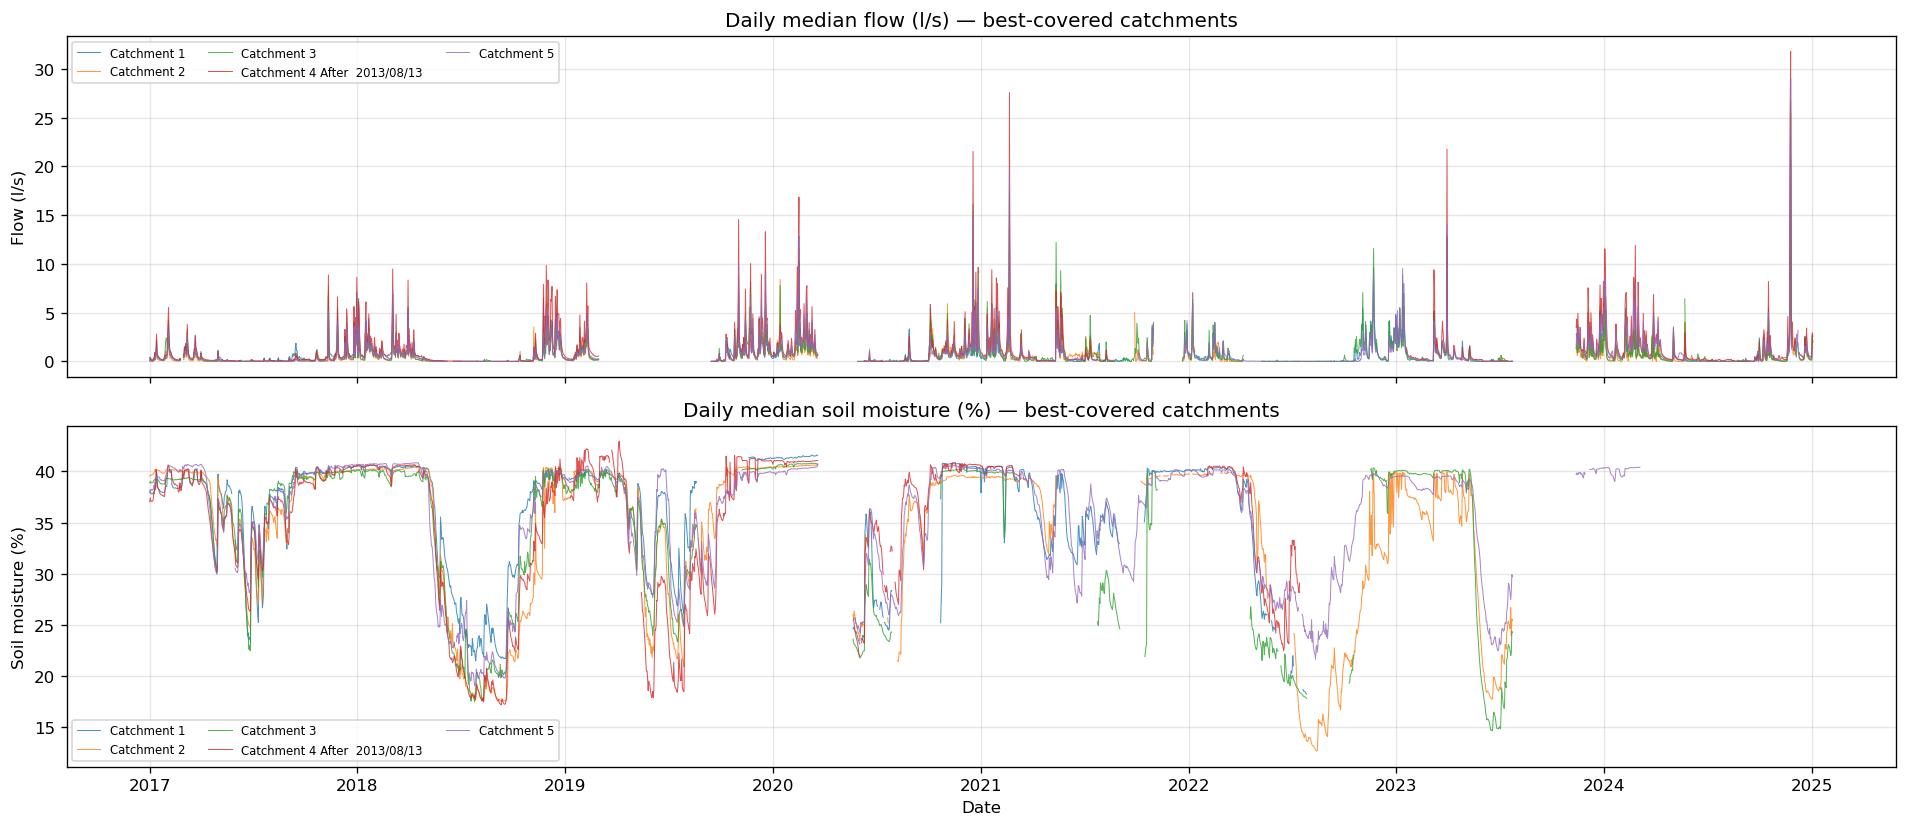

In [15]:
# Daily time series of flow and soil moisture across best-covered catchments
# Select catchments with >40% availability
best_flow = [c for c in flow_cols if apply_qc_filter(ms, c).notna().mean() > 0.4]
best_sm   = [c for c in sm_cols   if apply_qc_filter(ms, c).notna().mean() > 0.4]

ms["date"] = ms["Datetime"].dt.date

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for col in best_flow[:5]:
    s = apply_qc_filter(ms, col)
    ms_tmp = ms.copy(); ms_tmp["_v"] = s
    daily_f = ms_tmp.groupby("date")["_v"].median()
    daily_f.index = pd.to_datetime(daily_f.index)
    axes[0].plot(daily_f, lw=0.6, alpha=0.8, label=col.split("[")[-1].rstrip("]"))
axes[0].set_title("Daily median flow (l/s) — best-covered catchments")
axes[0].set_ylabel("Flow (l/s)")
axes[0].legend(fontsize=7, ncol=3)

for col in best_sm[:5]:
    s = apply_qc_filter(ms, col)
    ms_tmp = ms.copy(); ms_tmp["_v"] = s
    daily_s = ms_tmp.groupby("date")["_v"].median()
    daily_s.index = pd.to_datetime(daily_s.index)
    axes[1].plot(daily_s, lw=0.6, alpha=0.8, label=col.split("[")[-1].rstrip("]"))
axes[1].set_title("Daily median soil moisture (%) — best-covered catchments")
axes[1].set_ylabel("Soil moisture (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=7, ncol=3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(RESULTS / "measurements_timeseries.png", bbox_inches="tight")
plt.show()

# ─── 3. LIVESTOCK & MANAGEMENT ──────────────────────────────────────────────
# Animal location counts, weights, condition scores, field events

In [16]:
# Animal location counts — total head on farm per day per species
loc_cattle = pd.read_csv(DATA / "Animal_location_counts_Cattle_Basic_Data.csv")
loc_sheep  = pd.read_csv(DATA / "Animal_location_counts_Breeding_Sheep_Basic_Data.csv")
loc_lamb   = pd.read_csv(DATA / "Animal_location_counts_Lamb_Basic_Data.csv")

for df, name in [(loc_cattle, "Cattle"), (loc_sheep, "Sheep"), (loc_lamb, "Lamb")]:
    print(f"{name}: {df.shape}  |  columns: {list(df.columns[:6])}{'...' if len(df.columns)>6 else ''}")

Cattle: (2924, 22)  |  columns: ['Date', 'Catchment 1', 'Catchment 2', 'Catchment 3', 'Catchment 4 After  2013/08/13', 'Catchment 5']...
Sheep: (2924, 22)  |  columns: ['Date', 'Catchment 1', 'Catchment 2', 'Catchment 3', 'Catchment 4 After  2013/08/13', 'Catchment 5']...
Lamb: (2924, 22)  |  columns: ['Date', 'Catchment 1', 'Catchment 2', 'Catchment 3', 'Catchment 4 After  2013/08/13', 'Catchment 5']...


Cattle date range: 2017-01-01 → 2025-01-01
Mean cattle/day:   82
Mean sheep/day:    143
Mean lambs/day:    139


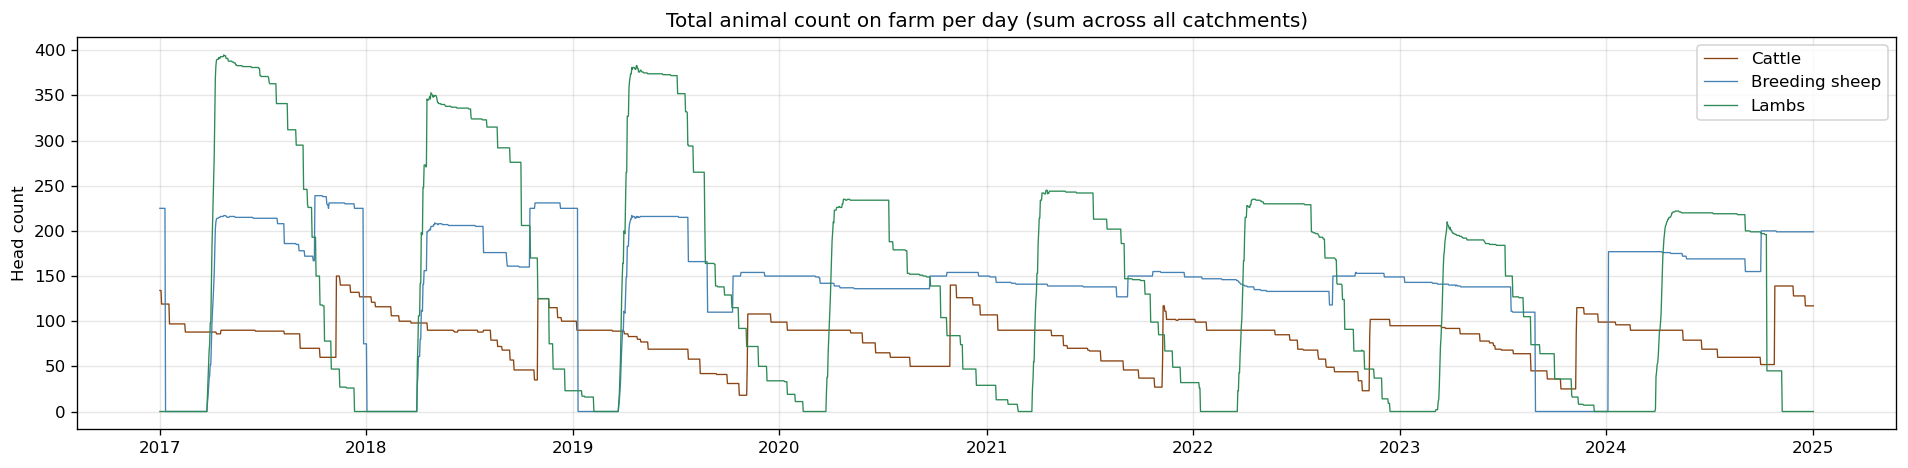

In [17]:
# Derive total head count per day for each species
# Data structure: rows = dates, columns = catchments (head count per catchment)
def daily_total_head(df):
    date_col = "Date"
    count_cols = [c for c in df.columns if c != date_col]
    dates = pd.to_datetime(df[date_col], errors="coerce")
    total = df[count_cols].sum(axis=1)
    result = pd.Series(total.values, index=dates).dropna(how="any")
    result = result[result.index.notna()].sort_index()
    return result

cattle_head = daily_total_head(loc_cattle)
sheep_head  = daily_total_head(loc_sheep)
lamb_head   = daily_total_head(loc_lamb)

print(f"Cattle date range: {cattle_head.index.min().date()} → {cattle_head.index.max().date()}")
print(f"Mean cattle/day:   {cattle_head.mean():.0f}")
print(f"Mean sheep/day:    {sheep_head.mean():.0f}")
print(f"Mean lambs/day:    {lamb_head.mean():.0f}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(cattle_head.index, cattle_head.values, lw=0.8, label="Cattle", color="saddlebrown")
ax.plot(sheep_head.index,  sheep_head.values,  lw=0.8, label="Breeding sheep", color="steelblue")
ax.plot(lamb_head.index,   lamb_head.values,   lw=0.8, label="Lambs", color="seagreen")
ax.set_title("Total animal count on farm per day (sum across all catchments)")
ax.set_ylabel("Head count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "livestock_counts.png", bbox_inches="tight")
plt.show()

In [18]:
# Livestock weights — distribution and trend over time
wt = pd.read_csv(DATA / "livestock_weight_long.csv")
print(f"Weight records: {len(wt):,}")
print(wt.head(3))
print(f"\nColumns: {list(wt.columns)}")
print(f"\nSpecies/types: {wt.iloc[:,1].value_counts().head(10).to_string() if wt.shape[1]>1 else 'N/A'}")

Weight records: 48,142
        Official tag Category Record_Date  Weight_kg         Species
0  UK 0 360476 00969      Ewe  2014-03-25       72.5  Breeding Sheep
1  UK 0 360476 00946      Ewe  2014-03-26       77.0  Breeding Sheep
2  UK 0 360476 01687      Ewe  2014-03-26       79.0  Breeding Sheep

Columns: ['Official tag', 'Category', 'Record_Date', 'Weight_kg', 'Species']

Species/types: Category
Lamb      20525
Ewe       15546
Cattle    12065
Ram           6


In [19]:
# Field events — fertiliser, spraying, reseeding etc.
events = pd.read_csv(DATA / "Field_Event_Data_Format_1.csv", parse_dates=True, low_memory=False)
print(f"Field events: {len(events):,}")
print(f"Columns: {list(events.columns)}")
print(f"\nSample:")
print(events.head(3).to_string())

date_col = "Event_Date"
type_col = "Field_Operation"
print(f"\nDate column: {date_col}")
print(f"Type column: {type_col}")
print(f"\nEvent type counts:")
print(events[type_col].value_counts().to_string())

Field events: 2,147
Columns: ['Event_Date', 'Time_IN', 'Time_Out', 'Time_in_field', 'Field', 'Tractor', 'Operator', 'Start_tractor_hours', 'End_tractor_hours', 'Total_tractor_hours', 'Field_Operation', 'Application', 'Total_application_in_Units', 'Units', 'Application_Info', 'Application_rate_per_ha', 'Application_batch_nr', 'Product_Name', 'Manufacturer']

Sample:
   Event_Date Time_IN Time_Out Time_in_field  Field  Tractor     Operator  Start_tractor_hours  End_tractor_hours  Total_tractor_hours   Field_Operation                                          Application  Total_application_in_Units Units                    Application_Info  Application_rate_per_ha Application_batch_nr         Product_Name Manufacturer
0  2017-03-29   15:00    15:30         00:30  NW038  MF 6470  Operator 11               2112.5             2113.0                  0.5  Apply Fertiliser  'Inorganic fertiliser application (macronutrients)'                       147.0    kg  (34.5% N; 0% P2O5; 0% K2O; 0% SO3) 

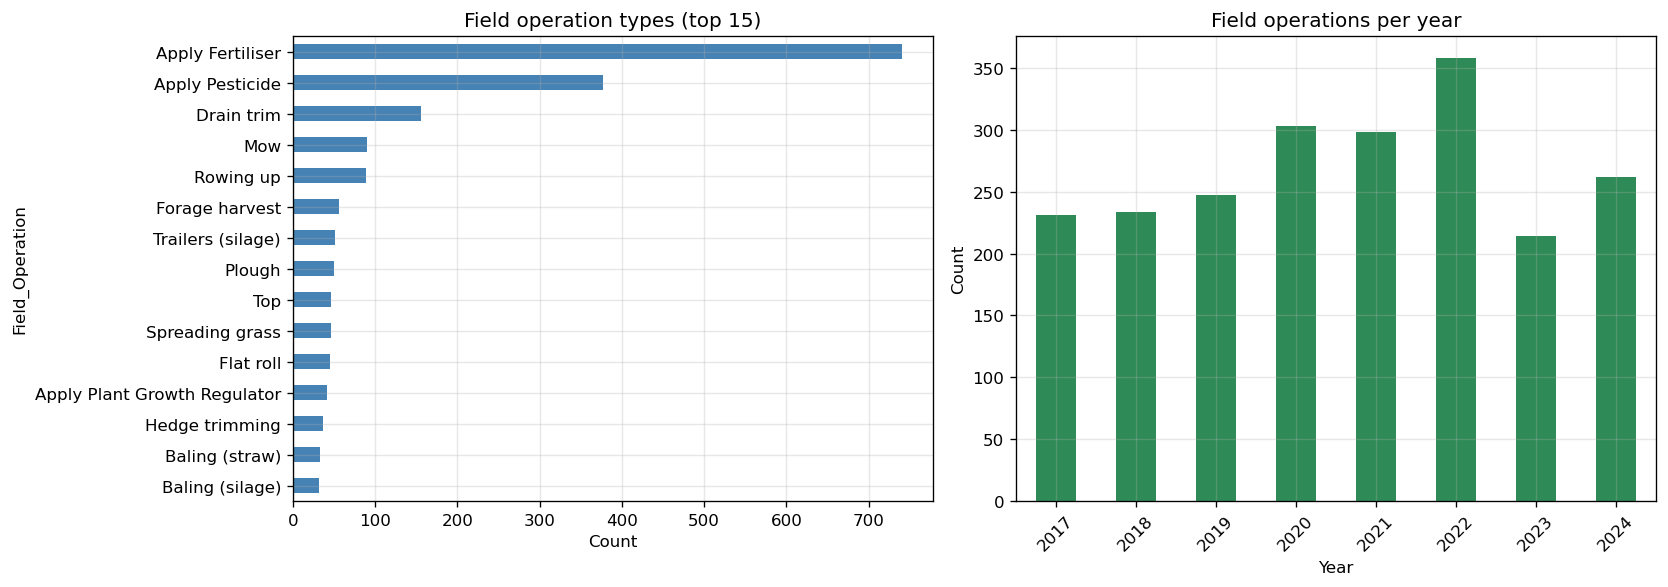

In [20]:
# Field event frequency by type and year
events["_date"] = pd.to_datetime(events[date_col], errors="coerce")
events["_year"] = events["_date"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = events[type_col].value_counts()
type_counts.head(15).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Field operation types (top 15)")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

year_counts = events.groupby("_year").size()
year_counts.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Field operations per year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS / "field_events.png", bbox_inches="tight")
plt.show()

# ─── 4. CROSS-DATASET ALIGNMENT ─────────────────────────────────────────────
# Align CH₄ flux, environmental drivers, and livestock counts on a common daily timeline

In [21]:
# Build a daily summary table: CH4, best soil moisture, best flow, cattle head count
# CH4 daily median (QC-filtered)
ch4_daily = gh_qc.groupby("date")[CH4].median().reset_index()
ch4_daily.columns = ["date", "ch4_median"]
ch4_daily["date"] = pd.to_datetime(ch4_daily["date"])

# Best soil moisture sensor (highest availability)
if best_sm:
    best_sm_col = max(best_sm, key=lambda c: apply_qc_filter(ms, c).notna().mean())
    sm_s = apply_qc_filter(ms, best_sm_col)
    ms_tmp = ms.copy(); ms_tmp["_sm"] = sm_s
    sm_daily = ms_tmp.groupby("date")["_sm"].median().reset_index()
    sm_daily.columns = ["date", "soil_moisture"]
    sm_daily["date"] = pd.to_datetime(sm_daily["date"])
else:
    sm_daily = pd.DataFrame(columns=["date", "soil_moisture"])

# Cattle head count daily
cattle_daily = cattle_head.reset_index()
cattle_daily.columns = ["date", "cattle_head"]
cattle_daily["date"] = pd.to_datetime(cattle_daily["date"])

# Merge on daily date
daily = (ch4_daily
    .merge(sm_daily, on="date", how="outer")
    .merge(cattle_daily, on="date", how="outer")
    .sort_values("date")
)

print(f"Merged daily table: {daily.shape}")
print(f"Date range: {daily['date'].min()} → {daily['date'].max()}")
print(daily.describe().round(2))

Merged daily table: (2924, 4)
Date range: 2017-01-01 00:00:00 → 2025-01-02 00:00:00
                      date  ch4_median  soil_moisture  cattle_head
count                 2924      468.00        2436.00      2923.00
mean   2021-01-01 12:00:00       10.70          35.12        82.11
min    2017-01-01 00:00:00      -55.23          23.21        18.00
25%    2019-01-01 18:00:00        1.48          32.37        67.00
50%    2021-01-01 12:00:00        5.74          36.87        90.00
75%    2023-01-02 06:00:00       17.91          38.77        95.00
max    2025-01-02 00:00:00      170.20          40.32       150.00
std                    NaN       19.62           4.64        24.96


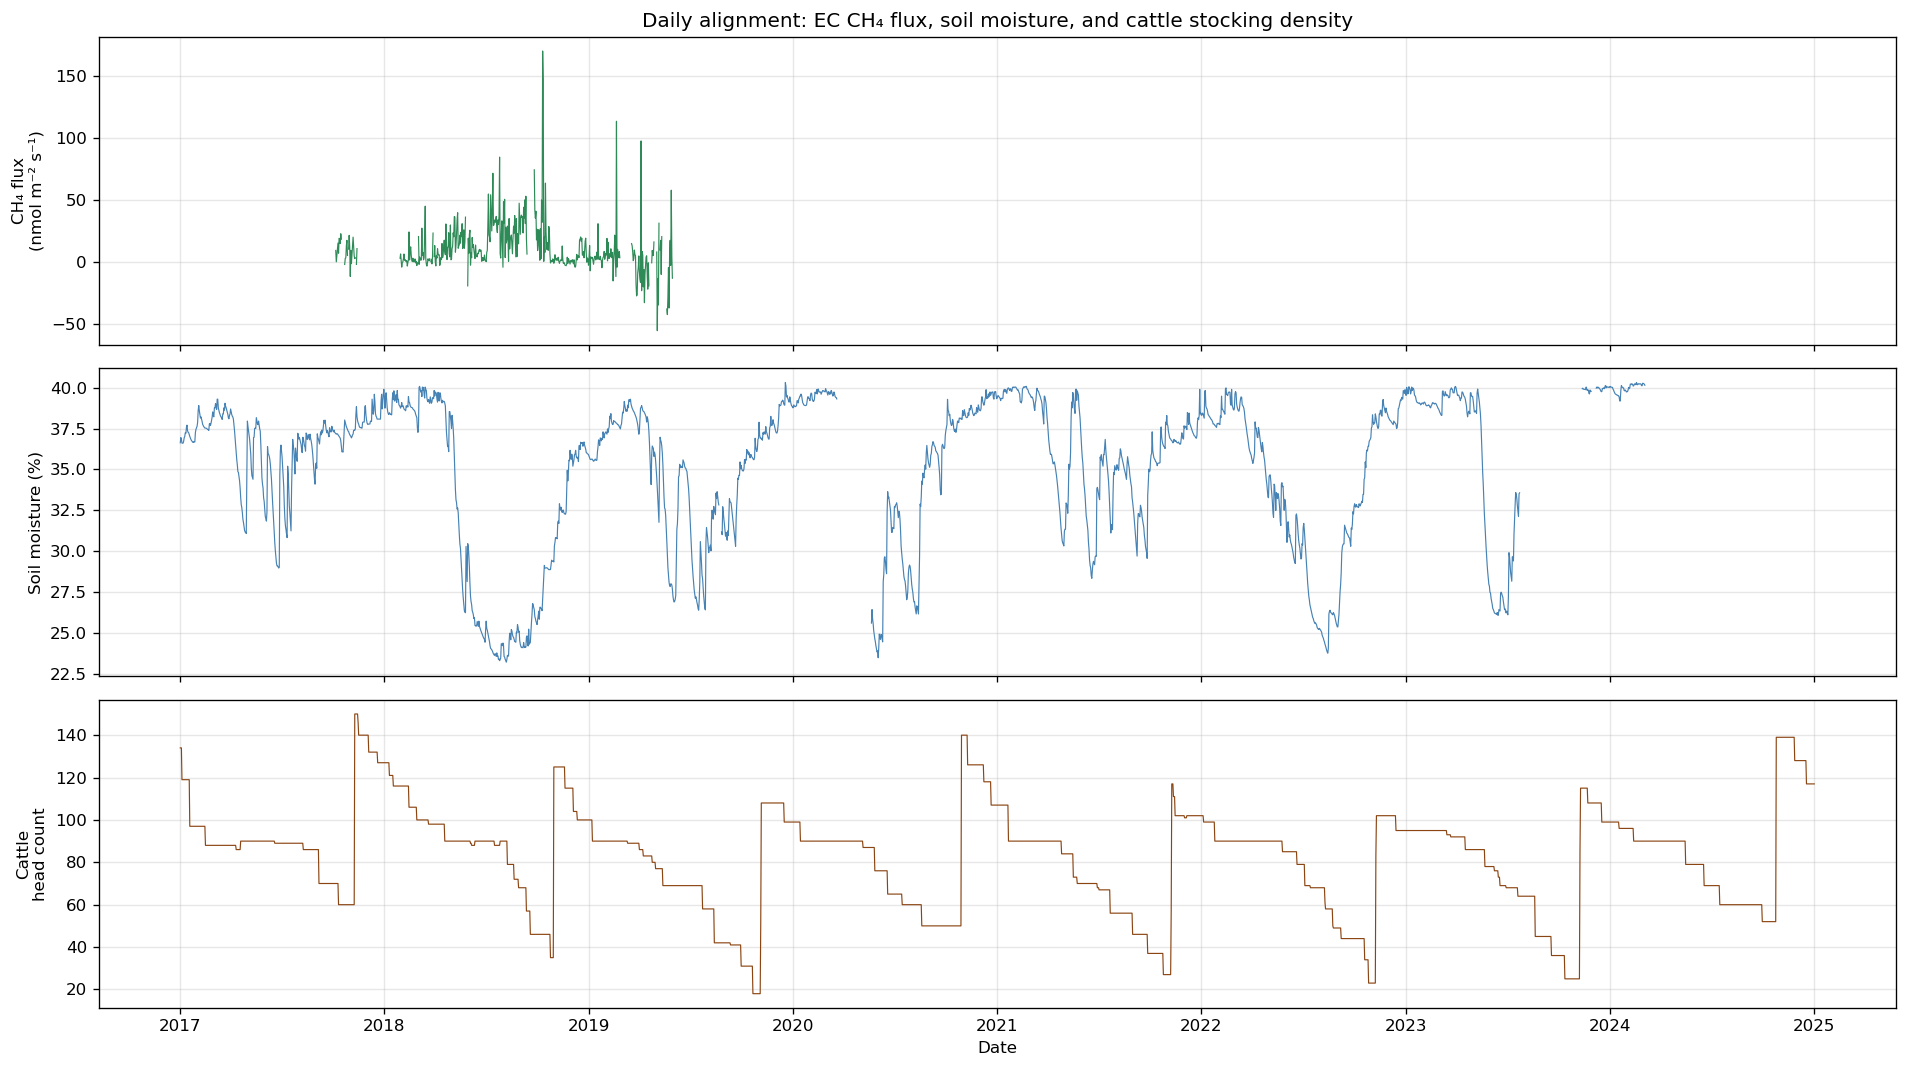

In [22]:
# Aligned time series: CH4, soil moisture, cattle stocking
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(daily["date"], daily["ch4_median"], lw=0.7, color="seagreen")
axes[0].set_ylabel("CH₄ flux\n(nmol m⁻² s⁻¹)")
axes[0].set_title("Daily alignment: EC CH₄ flux, soil moisture, and cattle stocking density")

if "soil_moisture" in daily.columns:
    axes[1].plot(daily["date"], daily["soil_moisture"], lw=0.7, color="steelblue")
    axes[1].set_ylabel("Soil moisture (%)")

axes[2].plot(daily["date"], daily["cattle_head"], lw=0.7, color="saddlebrown")
axes[2].set_ylabel("Cattle\nhead count")
axes[2].set_xlabel("Date")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(RESULTS / "cross_dataset_alignment.png", bbox_inches="tight")
plt.show()

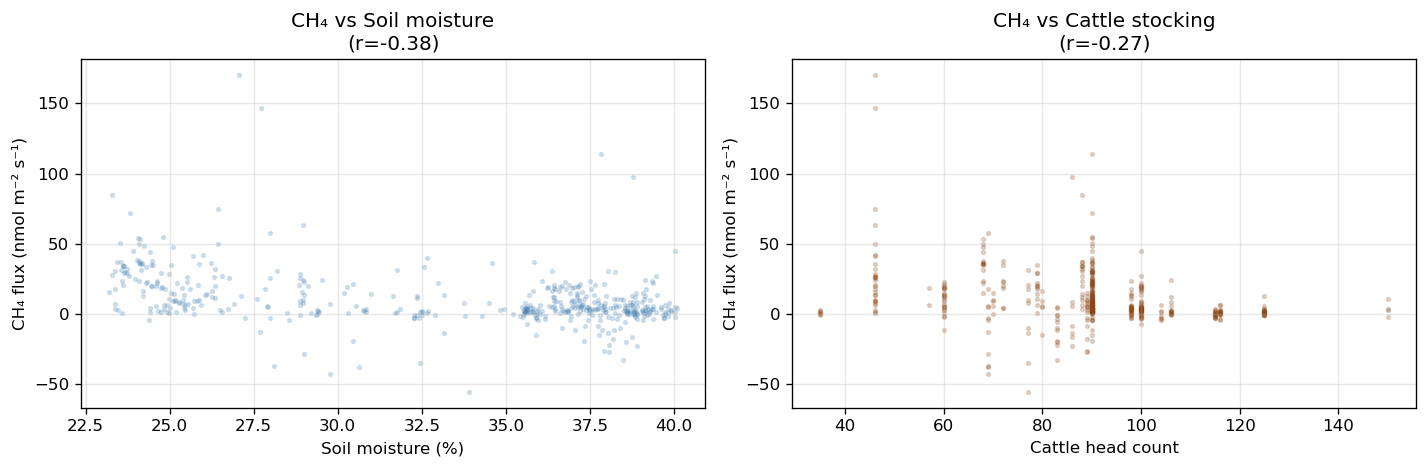

In [23]:
# Scatter: CH4 vs soil moisture and CH4 vs cattle head count
clean = daily.dropna(subset=["ch4_median"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "soil_moisture" in clean.columns and clean["soil_moisture"].notna().sum() > 10:
    sm_clean = clean.dropna(subset=["soil_moisture"])
    axes[0].scatter(sm_clean["soil_moisture"], sm_clean["ch4_median"], 
                    alpha=0.2, s=5, color="steelblue")
    axes[0].set_xlabel("Soil moisture (%)")
    axes[0].set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")
    axes[0].set_title(f"CH₄ vs Soil moisture\n(r={sm_clean['ch4_median'].corr(sm_clean['soil_moisture']):.2f})")

if clean["cattle_head"].notna().sum() > 10:
    cat_clean = clean.dropna(subset=["cattle_head"])
    axes[1].scatter(cat_clean["cattle_head"], cat_clean["ch4_median"], 
                    alpha=0.2, s=5, color="saddlebrown")
    axes[1].set_xlabel("Cattle head count")
    axes[1].set_ylabel("CH₄ flux (nmol m⁻² s⁻¹)")
    axes[1].set_title(f"CH₄ vs Cattle stocking\n(r={cat_clean['ch4_median'].corr(cat_clean['cattle_head']):.2f})")

plt.tight_layout()
plt.savefig(RESULTS / "ch4_scatter.png", bbox_inches="tight")
plt.show()

# ─── 5. EDA SUMMARY ─────────────────────────────────────────────────────────
# Key findings to carry forward into gap-filling and feature engineering

In [24]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\n[Greenhouse EC — primary target]")
print(f"  Column:          {CH4}")
print(f"  Period:          {gh['Datetime'].min().date()} → {gh['Datetime'].max().date()}")
print(f"  Total rows:      {len(gh):,}")
total_valid = gh["ch4_valid"].sum() if "ch4_valid" in gh.columns else gh[CH4].notna().sum()
print(f"  Valid (QC pass): {total_valid:,}  ({total_valid/len(gh)*100:.1f}%)")
print(f"  Contiguous gaps: {len(gaps):,}")
print(f"  Long gaps >12d:  {(gaps['duration_days']>12).sum()}")

print(f"\n[Measurements — environmental covariates]")
print(f"  Rows:            {len(ms):,}")
print(f"  Flow sensors:    {len(flow_cols)} columns, best coverage: {flow_avail.max():.0f}%")
print(f"  SM sensors:      {len(sm_cols)} columns, best coverage: {sm_avail.max():.0f}%")

print(f"\n[Livestock]")
print(f"  Cattle records:  {len(loc_cattle):,} animals tracked")
print(f"  Date range:      {cattle_head.index.min().date()} → {cattle_head.index.max().date()}")
print(f"  Mean cattle/day: {cattle_head.mean():.0f}")

print(f"\n[Field events]")
print(f"  Total events:    {len(events):,}")

print(f"\n[Next steps]")
print(f"  1. ERA5 download for gap periods > 12 days in CH4 (D-08)")
print(f"  2. Begin R-01: Irvin et al. RF gap-filling in 03_gap_filling/")
print(f"  3. Lag features: soil moisture, cattle counts from this EDA")

EDA SUMMARY

[Greenhouse EC — primary target]
  Column:          FCH4_1_1_1 [Tower 2]
  Period:          2017-01-01 → 2024-01-01
  Total rows:      122,679
  Valid (QC pass): 12,086  (9.9%)
  Contiguous gaps: 2,887
  Long gaps >12d:  5

[Measurements — environmental covariates]
  Rows:            280,608
  Flow sensors:    30 columns, best coverage: 84%
  SM sensors:      15 columns, best coverage: 83%

[Livestock]
  Cattle records:  2,924 animals tracked
  Date range:      2017-01-01 → 2025-01-01
  Mean cattle/day: 82

[Field events]
  Total events:    2,147

[Next steps]
  1. ERA5 download for gap periods > 12 days in CH4 (D-08)
  2. Begin R-01: Irvin et al. RF gap-filling in 03_gap_filling/
  3. Lag features: soil moisture, cattle counts from this EDA
